# Troncature d'une distribution

Montre comment la troncature d'une distribution sur un domaine est égale au produit par la loi uniforme sur ce domaine.


## Troncature de la distribution gaussienne unidimensionnelle

Pour une variable aléatoire $X$, de support réel, et dont la fonction de répartition est $F$ et la densité $f$, la densité de probabilité de la variable $X$ à l'intervalle réel $[a,b]$ est :
$$
f(x|a \leq X \leq b) = 
\begin{cases}
\frac{f(x)}{F(b)-F(a)} & \textrm{ pour tout } x\in[a,b],\\
0 & \textrm{sinon.}
\end{cases}
$$

La densité de probabilité de la loi normale d'espérance $\mu$, et d'écart type $\sigma$ est donnée par :
$$
\varphi(x) = \frac{1}{\sigma \sqrt{2\pi}}\operatorname e^{-\frac{1}{2} \left(\frac{x-\mu}{\sigma}\right)^2}
$$
pour tout $x\in[a,b]$

Considérons la variable $X \sim \mathcal N(\mu, \sigma^{2})$, et qu'on contraint $X$ à appartenir à l'intervalle $[a,b]$ avec $-\infty \leq a < b \leq \infty$. 
La densité tronquée est :
$$
f(x;\mu,\sigma, a,b) = \frac{\frac{1}{\sigma}}{\Phi\left(\frac{b - \mu}{\sigma}\right) - \Phi\left(\frac{a - \mu}{\sigma}\right) }\varphi\left(\frac{x - \mu}{\sigma}\right)
$$
pour tout $x\in[a,b]$, où $\Phi$ est la fonction de répartition de la loi Gaussienne.

In [1]:
import openturns as ot
import numpy as np
import pylab as pl

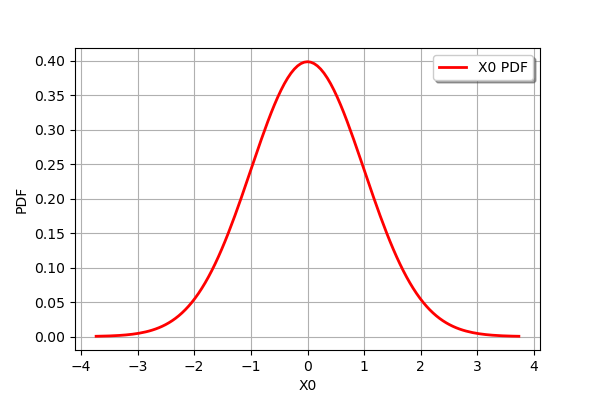

In [2]:
X = ot.Normal()
X.drawPDF()

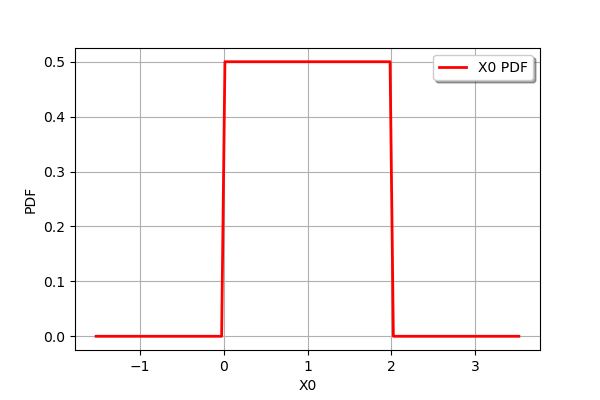

In [3]:
domain = ot.Interval([0.0], [2.0])
U = ot.Uniform(domain.getLowerBound()[0], domain.getUpperBound()[0])
U.drawPDF()

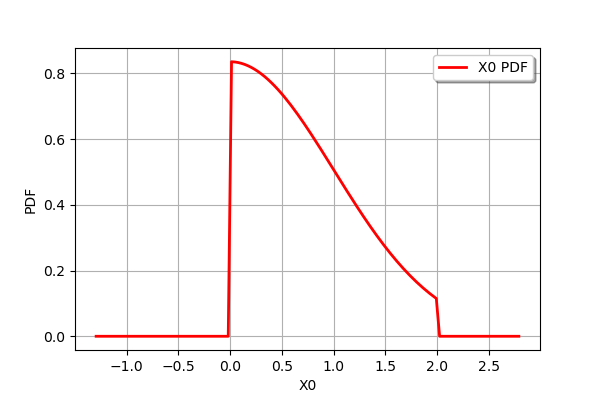

In [4]:
Z = ot.TruncatedDistribution(X, domain.getLowerBound()[0], domain.getUpperBound()[0])
Z.drawPDF()

## Produit

In [5]:
class PDFProduct(ot.PythonDistribution):
    """
    Create the random variable with product of PDFs.
    
    Its probability density function is proportionnal to the product 
    of the densities of f_X and f_Y. 
    The variable Z we create is *not* the product Z = X * Y, 
    because this is the random variable which is the product of two 
    independent random variables. 
    Here, we multiply the two densities. 
    
    If Y is uniform, this simplifies to truncating the distribution 
    X to the bounds in Y. 
    Similarily, if X is uniform, this simplifies to truncating the distribution 
    Y to the bounds in X.
    """

    def __init__(self, X, Y, monte_carlo_sampling_size=10000):
        super(PDFProduct, self).__init__(1)
        if X.getDimension() != 1:
            raise ValueError("Invalid dimension of X argument. Must be equal to 1.")
        if Y.getDimension() != 1:
            raise ValueError("Invalid dimension of Y argument. Must be equal to 1.")
        self.X = X
        self.Y = Y
        # Define range
        range_X = self.X.getRange()
        lower_bound_X = range_X.getLowerBound()
        upper_bound_X = range_X.getUpperBound()
        range_Y = self.Y.getRange()
        lower_bound_Y = range_Y.getLowerBound()
        upper_bound_Y = range_Y.getUpperBound()
        # Merge: the density is nonzero at intersetion
        self.range = range_X.intersect(range_Y)
        # Compute the normalization factor by Monte-Carlo sampling.
        lower_bound = self.getRange().getLowerBound()
        rule = ot.GaussKronrodRule(ot.GaussKronrodRule.G11K23)
        maximumSubIntervals = 100
        maximumError = 1.e-8
        algo = ot.GaussKronrod(maximumSubIntervals, maximumError, rule)
        def product_pdf_function(P):
            X_pdf = X.computePDF(P)
            Y_pdf = Y.computePDF(P)
            product_pdf = X_pdf * Y_pdf
            return [product_pdf]
        integrand = ot.PythonFunction(1, 1, product_pdf_function)
        self.factor = algo.integrate(integrand, self.range)[0]

    def getFactor(self):
        return self.factor

    def getRange(self):
        return self.range

    def computePDF(self, P):
        pdf_X = self.X.computePDF(P)
        pdf_Y = self.Y.computePDF(P)
        pdf_product = pdf_X * pdf_Y / self.factor        
        return pdf_product
    
    def computeCDF(self, P):
        lower_bound = self.getRange().getLowerBound()
        rule = ot.GaussKronrodRule(ot.GaussKronrodRule.G11K23)
        maximumSubIntervals = 100
        maximumError = 1.e-8
        algo = ot.GaussKronrod(maximumSubIntervals, maximumError, rule)
        def pdffunction(P):
            pdf = self.computePDF(P)
            return [pdf]
        integrand = ot.PythonFunction(1, 1, pdffunction)
        interval = ot.Interval(lower_bound, P)
        cdf = algo.integrate(integrand, interval)[0]
        return cdf    

In [6]:
Z = ot.Distribution(PDFProduct(U, X))

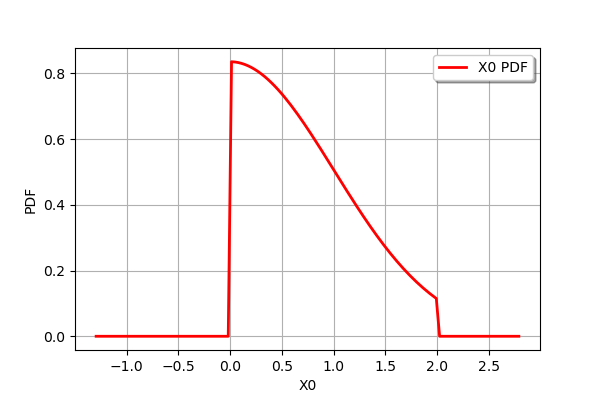

In [7]:
Z.drawPDF()

## Gaussienne en dimension 2

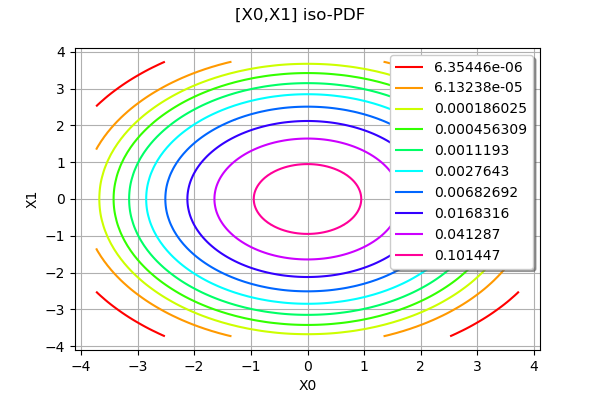

In [8]:
X = ot.Normal(2)
graph = X.drawPDF()
graph

In [9]:
bounds = graph.getBoundingBox()

In [10]:
domain = ot.Interval([0.0, 1.0], [2.0, 3.0])
U1 = ot.Uniform(domain.getLowerBound()[0], domain.getUpperBound()[0])
U2 = ot.Uniform(domain.getLowerBound()[1], domain.getUpperBound()[1])
U = ot.ComposedDistribution([U1, U2])

In [11]:
def drawInTheBounds(vLow, vUp, n_test):
    """
    Draw the area within the bounds.
    """
    palette = ot.Drawable.BuildDefaultPalette(2)
    myPaletteColor = palette[1]
    polyData = [[vLow[i], vLow[i + 1], vUp[i + 1], vUp[i]] for i in range(n_test - 1)]
    polygonList = [
        ot.Polygon(polyData[i], myPaletteColor, myPaletteColor)
        for i in range(n_test - 1)
    ]
    boundsPoly = ot.PolygonArray(polygonList)
    return boundsPoly

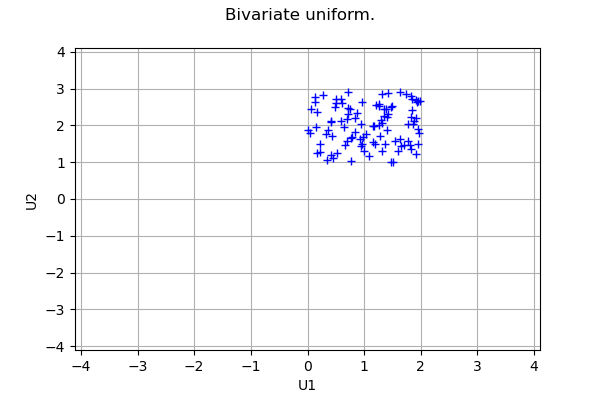

In [12]:
sample = U.getSample(100)
graph = ot.Graph("Bivariate uniform.", "U1", "U2", True)
cloud = ot.Cloud(sample)
graph.add(cloud)
graph.setBoundingBox(bounds)
graph

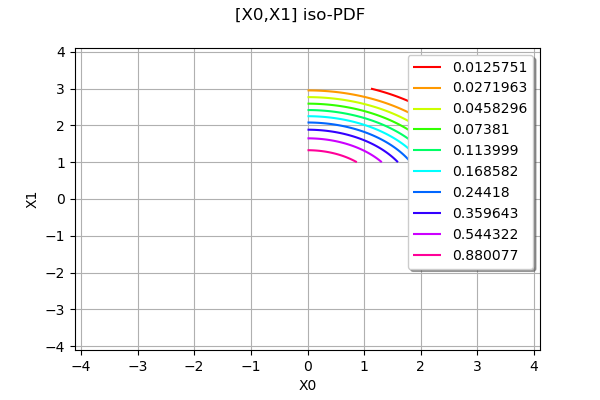

In [13]:
Z = ot.TruncatedDistribution(X, domain)
graph = Z.drawPDF()
graph.setBoundingBox(bounds)
graph

## Expérience de produit de densités

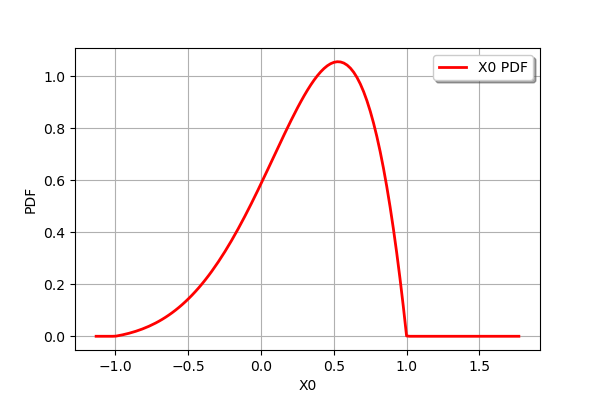

In [14]:
X = ot.Beta()
Y = ot.Normal(2.0, 1.0)
Z = ot.Distribution(PDFProduct(X, Y))
Z.drawPDF()

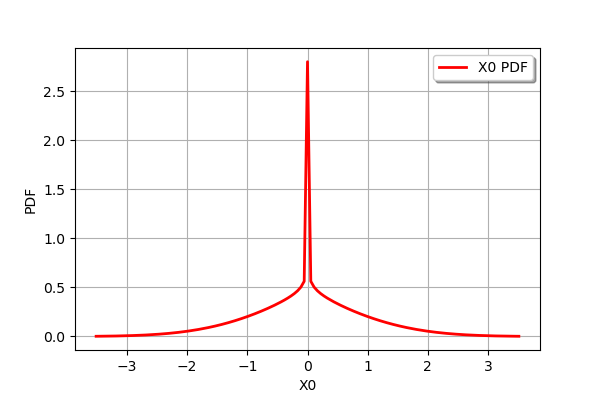

In [15]:
Z = X * Y
Z.drawPDF()

Conclusions.
* La variable aléatoire n'est pas la variable "produit". 
* La variable aléatoire que l'on a créé n'est pas dans OpenTURNS. 